In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path
import re
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import seaborn as sns

def snv(X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
      m = X.mean()
      s = X.std()
      return (X - m) / (s if s != 0 else 1.0)
    m = X.mean(axis=1, keepdims=True)
    s = X.std(axis=1, keepdims=True)
    s[s == 0] = 1.0
    return (X - m) / s

In [3]:
df_peso = pd.read_csv("peso_60.csv")

dia_col = df_peso.columns[0]
quesos = df_peso.columns[1:]
peso_inicial = df_peso[quesos].apply(lambda s: s.dropna().iloc[0])
df_peso_rel = df_peso[quesos].divide(peso_inicial, axis=1) * 100
df_peso_rel = pd.concat([df_peso[[dia_col]], df_peso_rel], axis=1)

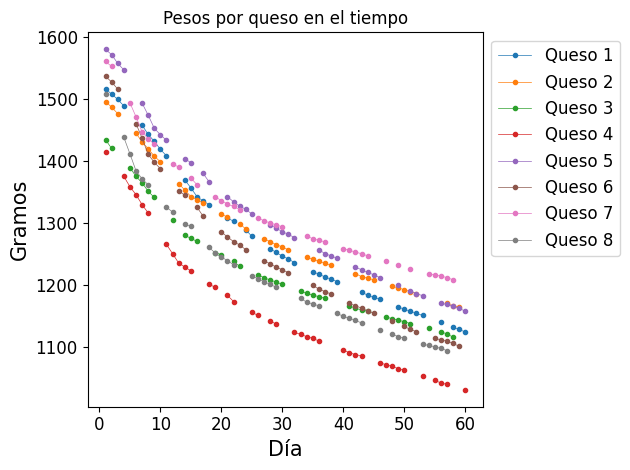

In [4]:
plt.figure()
for q in quesos:
  plt.plot(df_peso[dia_col], df_peso[q], marker="o", linewidth=0.5, markersize=3, label=str(q))
plt.xlabel("Día", fontsize=15)
plt.ylabel("Gramos", fontsize=15)
plt.title("Pesos por queso en el tiempo")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
tabla = pd.DataFrame({
    "peso_inicial_g": peso_inicial,
    "peso_final_g": df_peso[quesos].apply(lambda s: s.dropna().iloc[-1]),
    "perdida_g": df_peso[quesos].apply(lambda s: s.dropna().iloc[-1])-peso_inicial,
    "perdida_%": (df_peso[quesos].apply(lambda s: s.dropna().iloc[-1])/peso_inicial - 1)*100
})
tabla

,peso_inicial_g,peso_final_g,perdida_g,perdida_%
Queso 1,1516.5,1125.0,-391.5,-25.816024
Queso 2,1496.0,1165.0,-331.0,-22.125668
Queso 3,1434.5,1116.5,-318.0,-22.168003
Queso 4,1414.5,1032.0,-382.5,-27.041357
Queso 5,1580.0,1158.5,-421.5,-26.677215
Queso 6,1536.5,1102.0,-434.5,-28.278555
Queso 7,1560.5,1209.0,-351.5,-22.524832
Queso 8,1507.5,1095.0,-412.5,-27.363184


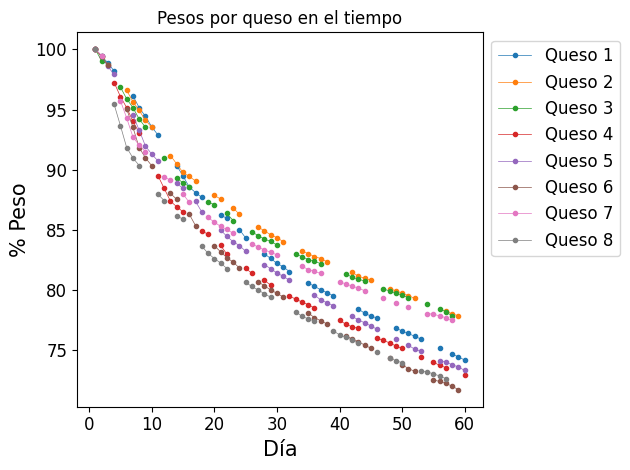

In [6]:
plt.figure()
for q in quesos:
  plt.plot(df_peso_rel[dia_col], df_peso_rel[q], marker="o", linewidth=0.5, markersize=3, label=str(q))
plt.xlabel("Día", fontsize=15)
plt.ylabel("% Peso", fontsize=15)
plt.title("Pesos por queso en el tiempo")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Queso 1 {'d': 22, 'sse': np.float64(5.28429816938629), 'slope1': np.float64(-0.7195703216560948), 'slope2': np.float64(-0.28288778810152126), 'r2_1': np.float64(0.9921588085841858), 'r2_2': np.float64(0.9896420095174363)}
Queso 2 {'d': 17, 'sse': np.float64(3.36082617062166), 'slope1': np.float64(-0.7153616213959715), 'slope2': np.float64(-0.24739777602851235), 'r2_1': np.float64(0.99701268506092), 'r2_2': np.float64(0.9870680913869374)}
Queso 3 {'d': 16, 'sse': np.float64(3.262135976460995), 'slope1': np.float64(-0.7843548367088868), 'slope2': np.float64(-0.22909350885571358), 'r2_1': np.float64(0.9965841522595661), 'r2_2': np.float64(0.9864638091593999)}
Queso 4 {'d': 15, 'sse': np.float64(6.54127868477813), 'slope1': np.float64(-1.0233683882310634), 'slope2': np.float64(-0.27563915968216424), 'r2_1': np.float64(0.9948136772298092), 'r2_2': np.float64(0.9830419126890761)}
Queso 5 {'d': 18, 'sse': np.float64(8.568183084223817), 'slope1': np.float64(-0.8223163107737363), 'slope2': np.f

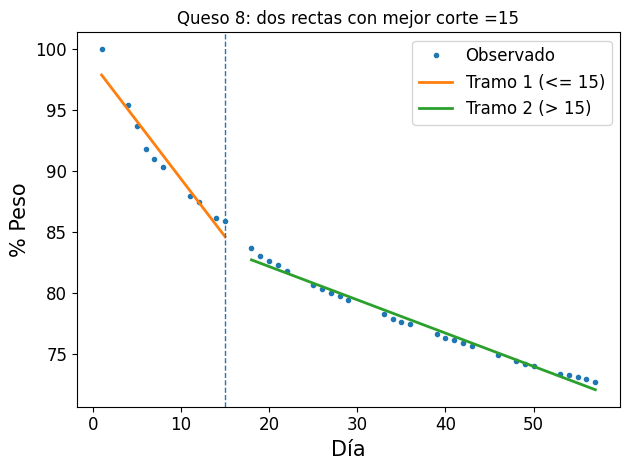

In [ ]:
d_min = 5
d_max = 30

for q in quesos:
  best = None
  tmp = df_peso_rel[[dia_col, q]].dropna()

  for d in range(d_min, d_max+1):
    mask1 = tmp[dia_col] <= d
    mask2 =tmp[dia_col] > d

    r1 = linregress(tmp[dia_col][mask1], tmp[q][mask1])
    r2 = linregress(tmp[dia_col][mask2], tmp[q][mask2])

    sse1 = np.sum((tmp[q][mask1] - (r1.intercept + r1.slope*tmp[dia_col][mask1]))**2)
    sse2 = np.sum((tmp[q][mask2] - (r2.intercept + r2.slope*tmp[dia_col][mask2]))**2)
    sse = sse1 + sse2#nos quedamos el minimo error entre las dos rectas

    if best is None or sse < best["sse"]:
      best = {"d": d, "sse": sse, "slope1": r1.slope, "slope2": r2.slope, "r2_1": r1.rvalue**2, "r2_2": r2.rvalue**2}
  print(q, best)


mask1 = tmp[dia_col] <= best['d']
mask2 = tmp[dia_col] > best['d']

r1 = linregress(tmp.loc[mask1, dia_col], tmp.loc[mask1, q])
r2 = linregress(tmp.loc[mask2, dia_col], tmp.loc[mask2, q])

plt.figure()
plt.plot(tmp[dia_col], tmp[q], "o", markersize=3, label="Observado")
plt.plot(tmp[dia_col][mask1], r1.intercept + r1.slope*tmp[dia_col][mask1], linewidth=2, label=f"Tramo 1 (<= {best['d']})")
plt.plot(tmp[dia_col][mask2], r2.intercept + r2.slope*tmp[dia_col][mask2], linewidth=2, label=f"Tramo 2 (> {best['d']})")
plt.axvline(best['d'], linestyle="--", linewidth=1)
plt.xlabel("Día", fontsize=15)
plt.ylabel("% Peso", fontsize=15)
plt.title(f"{q}: dos rectas con mejor corte ={best['d']}")
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
df_ch = pd.read_csv("nir_raw_60.csv")
data_snv = snv(df_ch.iloc[:, :-3].to_numpy())

df_ch_snv = df_ch.copy()
df_ch_snv.iloc[:, :-3] = data_snv
df_ch_median = (df_ch_snv
                .groupby(["cheese_id", "day"], as_index=False)[df_ch_snv.columns[:-3]]
                .median())

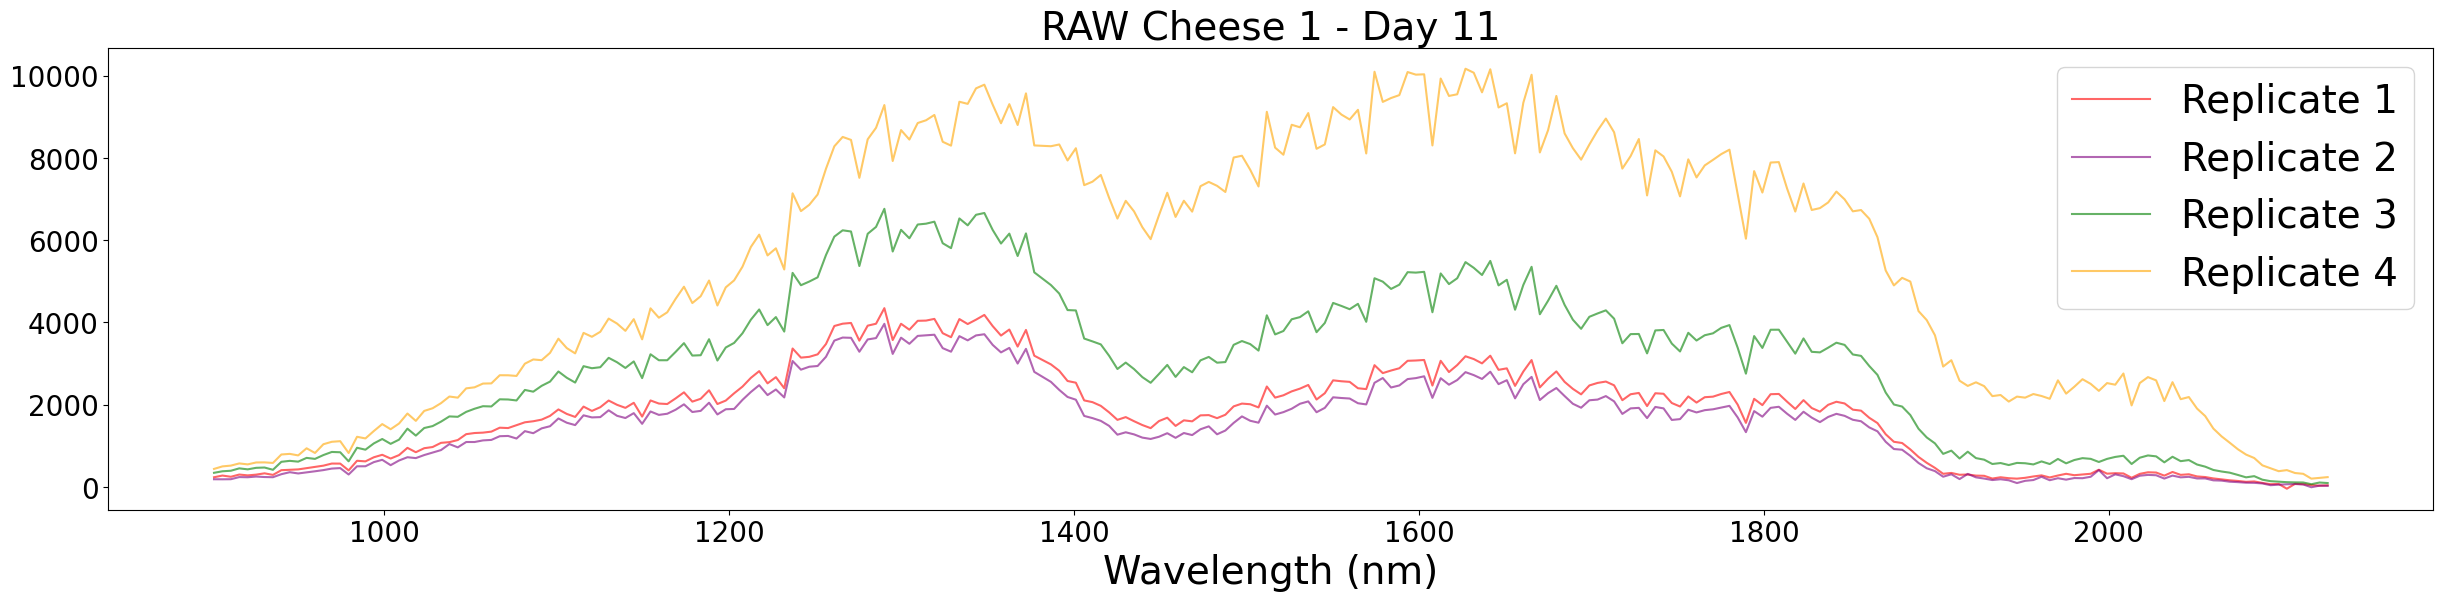

In [40]:
sample = 2
colors = ['red', 'purple', 'green', 'orange']

X = df_ch.iloc[sample*4:(sample*4)+4, :-3]
cheese_id = df_ch.iloc[sample*4, -3]
day = df_ch.iloc[sample*4, -2]

wl = X.columns.astype(float).to_numpy()

plt.figure(figsize=(30,6))
for i in range(X.shape[0]):
    plt.plot(wl, X.iloc[i, :].to_numpy(), alpha=0.6, color=colors[i], label=f"Replicate {i+1}")

plt.title(f"RAW Cheese {cheese_id} - Day {day}", fontsize=28)
plt.xlabel("Wavelength (nm)", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=28)
plt.show()

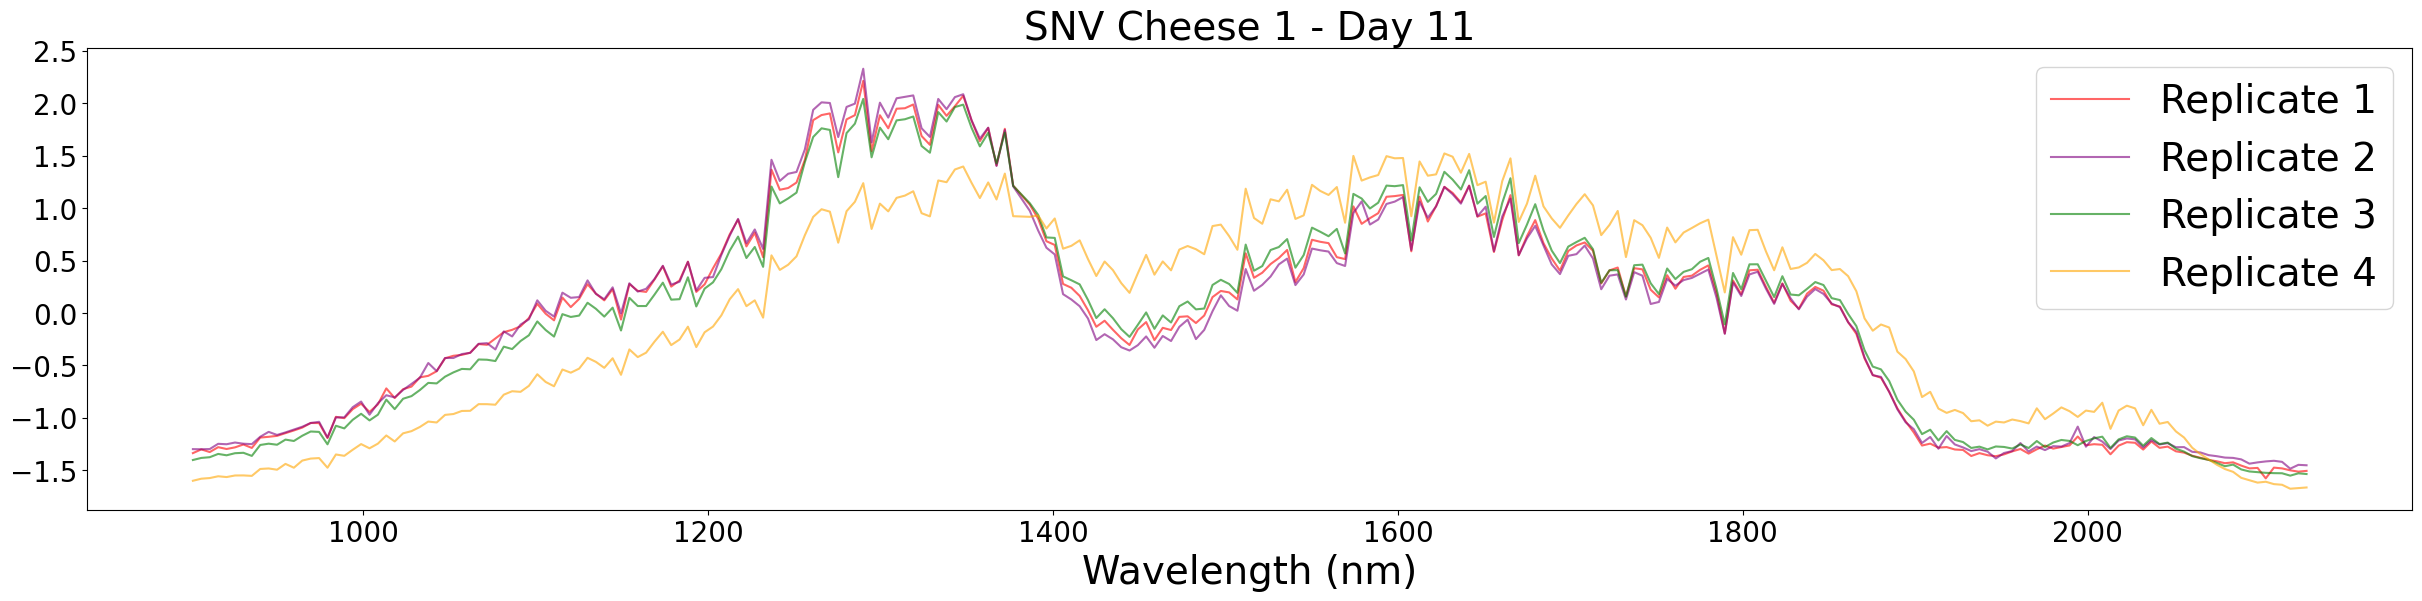

In [42]:
X = df_ch_snv.iloc[sample*4:(sample*4)+4, :-3]
cheese_id = df_ch_snv.iloc[sample*4, -3]
day = df_ch_snv.iloc[sample*4, -2]

wl = X.columns.astype(float).to_numpy()

plt.figure(figsize=(30,6))
for i in range(X.shape[0]):
    plt.plot(wl, X.iloc[i, :].to_numpy(), alpha=0.6, color=colors[i], label=f"Replicate {i+1}")

plt.title(f"SNV Cheese {cheese_id} - Day {day}", fontsize=28)
plt.xlabel("Wavelength (nm)", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=28)
plt.show()

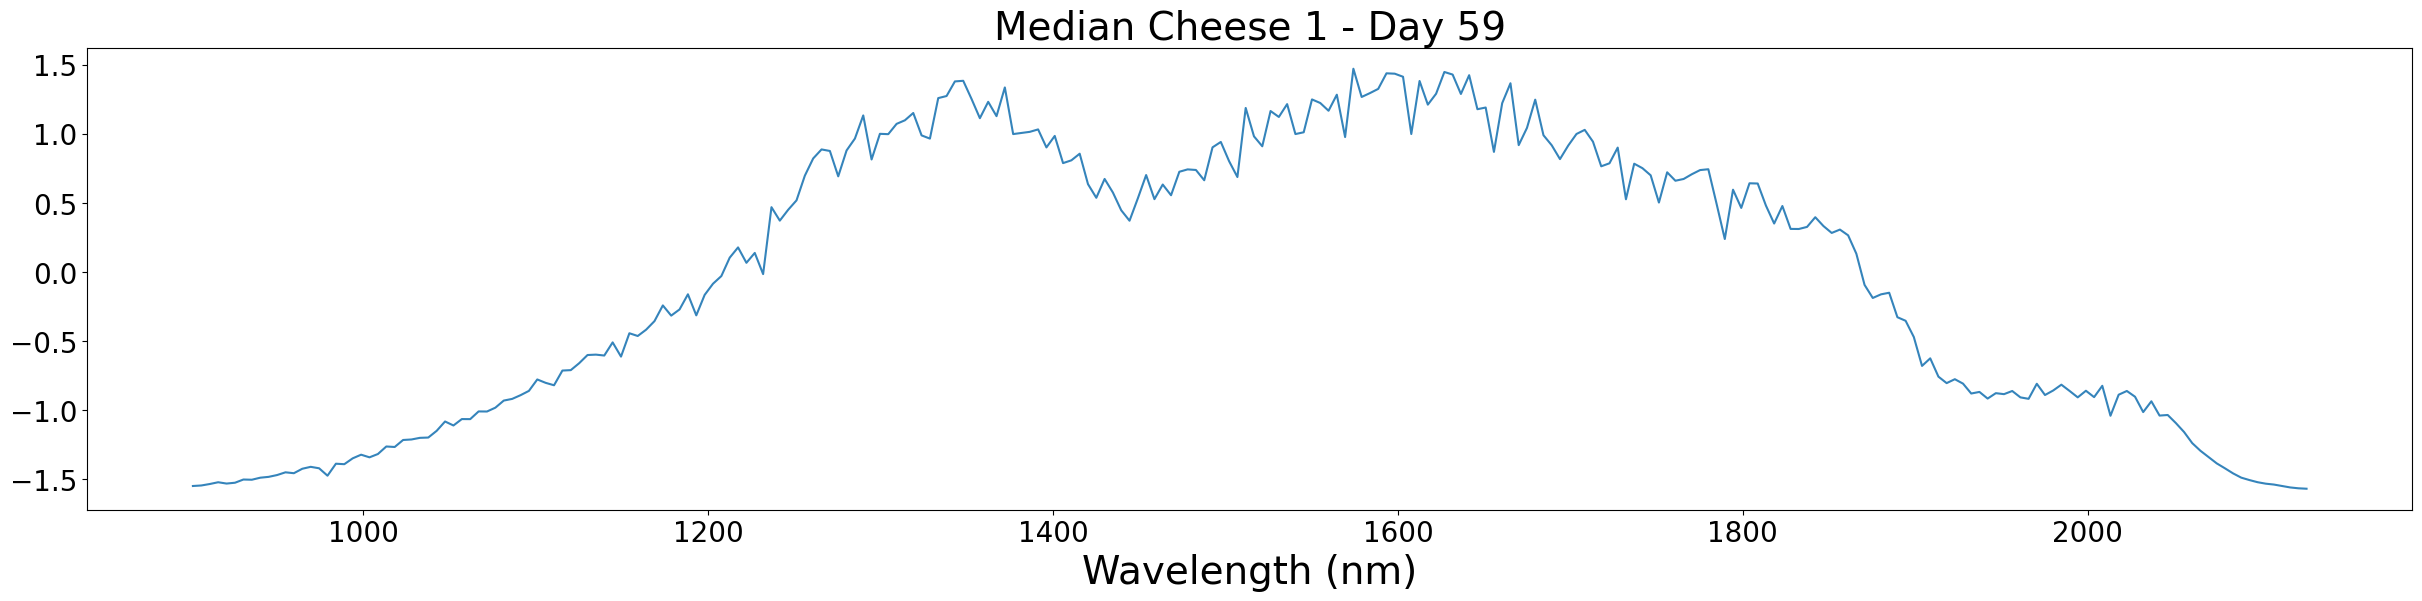

In [43]:
X = df_ch_median.iloc[34]
cheese_id = X["cheese_id"].astype(int)
day = X["day"].astype(int)

X = X.drop(labels=["cheese_id", "day"])

wl = X.index.astype(float).to_numpy()

plt.figure(figsize=(30, 6))
plt.plot(wl, X, alpha=0.9, color='tab:blue')
plt.title(f"Median Cheese {cheese_id} - Day {day}", fontsize=28)
plt.xlabel("Wavelength (nm)", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

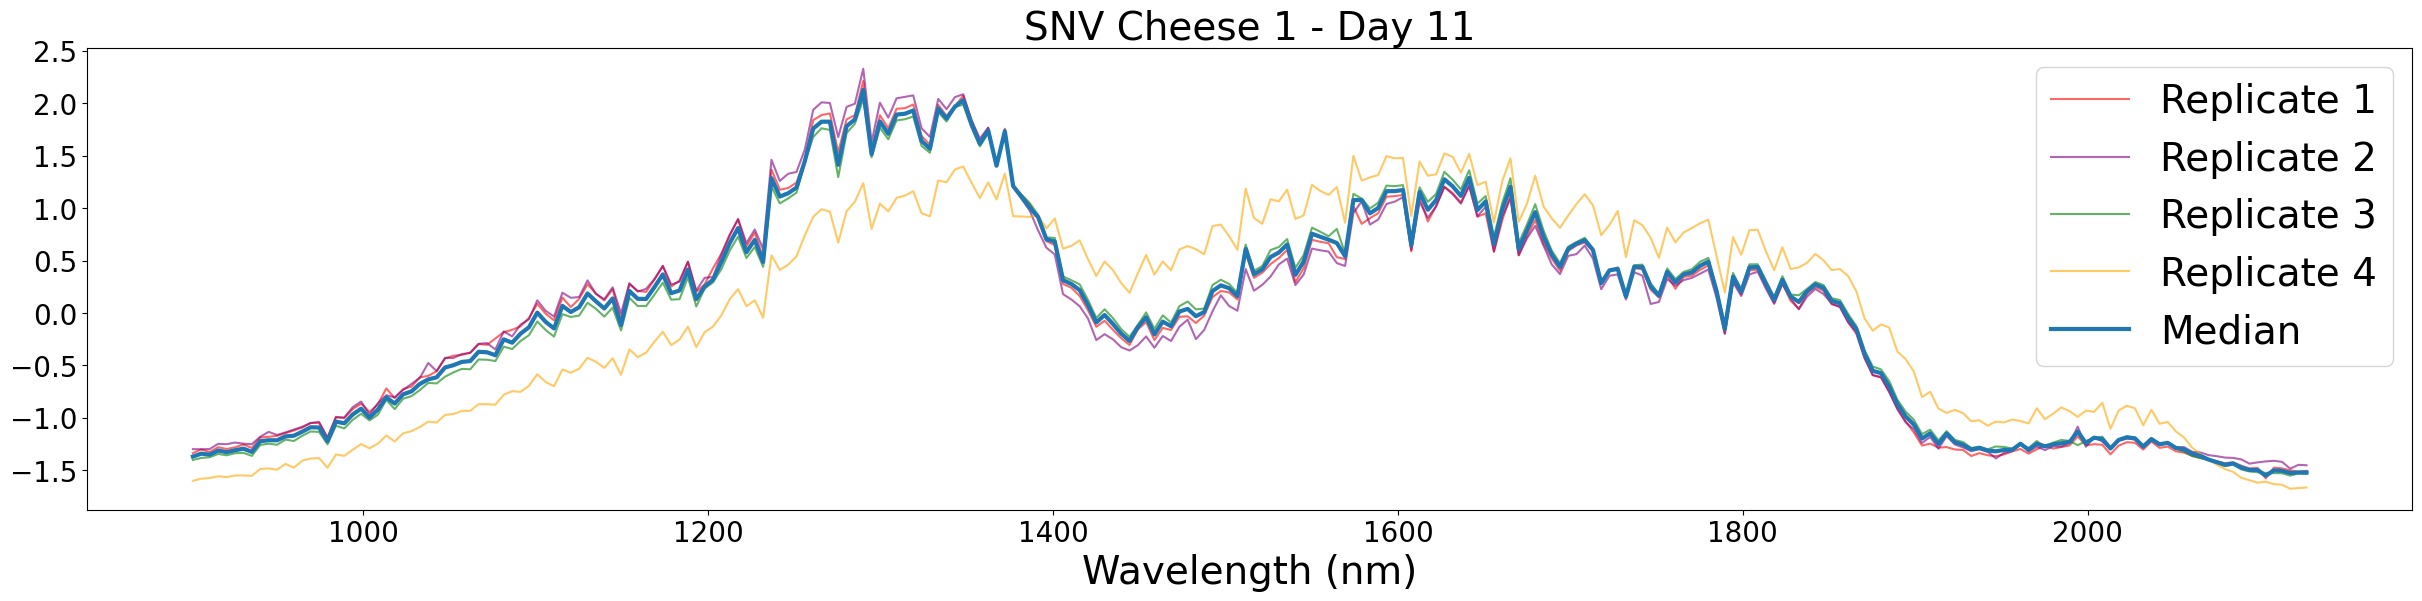

In [44]:
X = df_ch_snv.iloc[sample*4:(sample*4)+4, :-3]
cheese_id = df_ch_snv.iloc[sample*4, -3]
day = df_ch_snv.iloc[sample*4, -2]

X2 = df_ch_median.iloc[8]
X2 = X2.drop(labels=["cheese_id", "day"])
wl = X.columns.astype(float).to_numpy()

plt.figure(figsize=(30,6))


for i in range(X.shape[0]):
    plt.plot(wl, X.iloc[i, :].to_numpy(), alpha=0.6, color=colors[i], label=f"Replicate {i+1}")

plt.plot(wl, X2.to_numpy(), linewidth=3, color='tab:blue', label="Median")

plt.title(f"SNV Cheese {cheese_id} - Day {day}", fontsize=28)
plt.xlabel("Wavelength (nm)", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=28)
plt.show()

In [8]:
df_all = pd.read_csv("nir_clean_rel.csv")
X = df_all.iloc[:,2:-1]
y_day = df_all['day']
y_gr = df_all['gr']

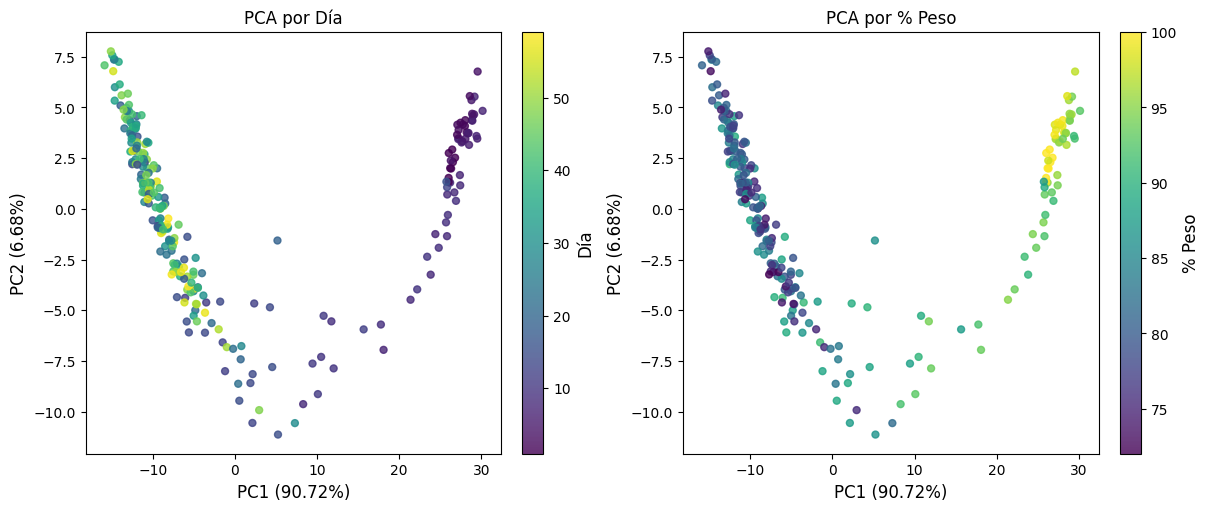

In [10]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

sc1 = ax[0].scatter(X_pca[:,0], X_pca[:,1], c=y_day, cmap="viridis", alpha=0.8, s=25)
cbar = fig.colorbar(sc1, ax=ax[0])
cbar.set_label("Día", fontsize=12)
ax[0].set_title("PCA por Día")
ax[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
ax[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)

sc2 = ax[1].scatter(X_pca[:,0], X_pca[:,1], c=y_gr, cmap="viridis", alpha=0.8, s=25)
cbar = fig.colorbar(sc2, ax=ax[1])
cbar.set_label("% Peso", fontsize=12)
ax[1].set_title("PCA por % Peso")
ax[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
ax[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)

plt.show()



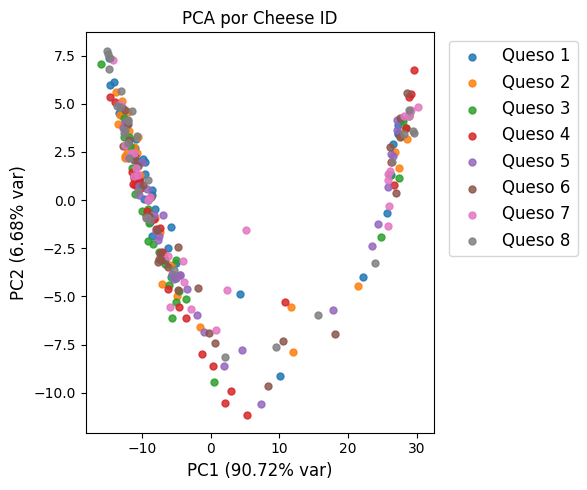

In [13]:
cheese_id = df_all['cheese_id']
unique_cheese = np.sort(np.unique(cheese_id))

plt.figure(figsize=(6,5))
for cid in unique_cheese:
  mask = (cheese_id == cid)
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=25, alpha=0.85, label=f"Queso {cid}")

plt.title("PCA por Cheese ID")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

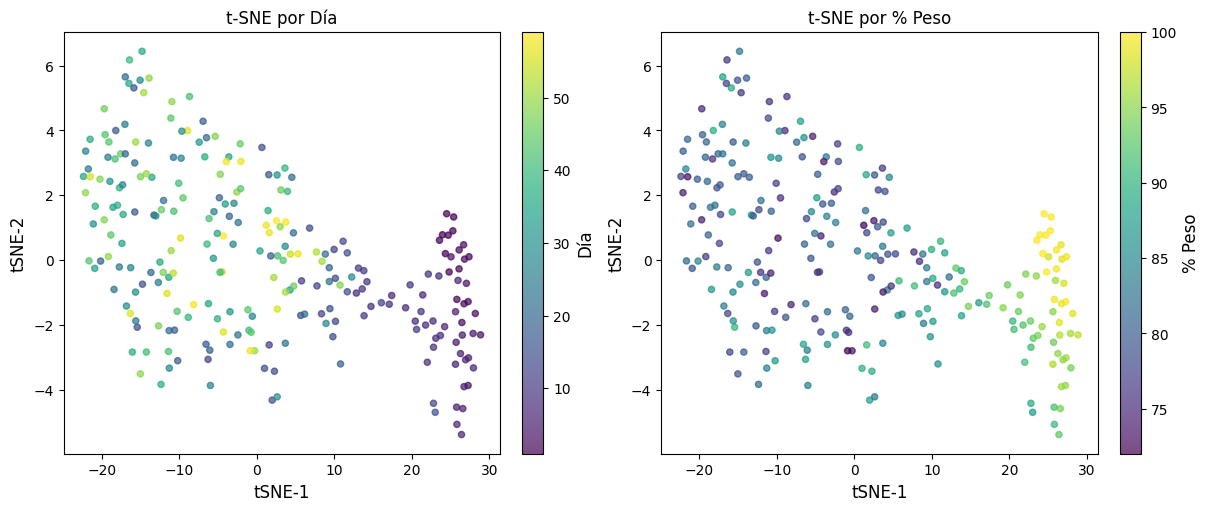

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


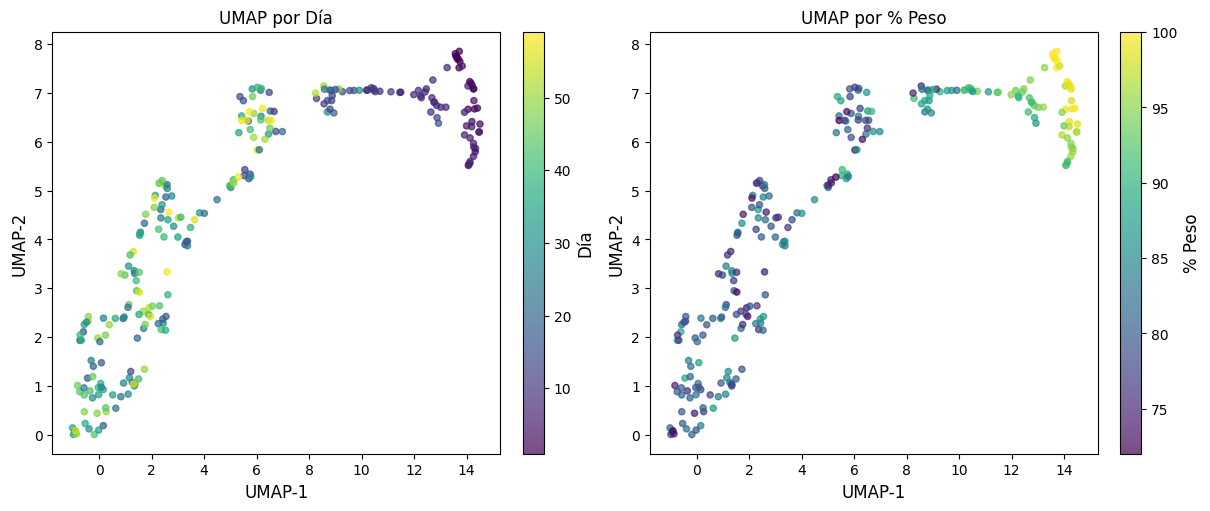

In [22]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto").fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sc1 = ax[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_day, cmap="viridis", s=20, alpha=0.7)
cbar = fig.colorbar(sc1, ax=ax[0])
cbar.set_label("Día", fontsize=12)
ax[0].set_title("t-SNE por Día")
ax[0].set_xlabel("tSNE-1", fontsize=12)
ax[0].set_ylabel("tSNE-2", fontsize=12)

sc2 = ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_gr, cmap="viridis", s=20, alpha=0.7)
cbar = fig.colorbar(sc2, ax=ax[1])
cbar.set_label("% Peso", fontsize=12)
ax[1].set_title("t-SNE por % Peso")
ax[1].set_xlabel("tSNE-1", fontsize=12)
ax[1].set_ylabel("tSNE-2", fontsize=12)

plt.show()


reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sc1 = ax[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y_day, cmap="viridis", s=20, alpha=0.7)
cbar = fig.colorbar(sc1, ax=ax[0])
cbar.set_label("Día", fontsize=12)
ax[0].set_title("UMAP por Día")
ax[0].set_xlabel("UMAP-1", fontsize=12)
ax[0].set_ylabel("UMAP-2", fontsize=12)

sc2 = ax[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_gr, cmap="viridis", s=20, alpha=0.7)
cbar = fig.colorbar(sc2, ax=ax[1])
cbar.set_label("% Peso", fontsize=12)
ax[1].set_title("UMAP por % Peso")
ax[1].set_xlabel("UMAP-1", fontsize=12)
ax[1].set_ylabel("UMAP-2", fontsize=12)

plt.show()

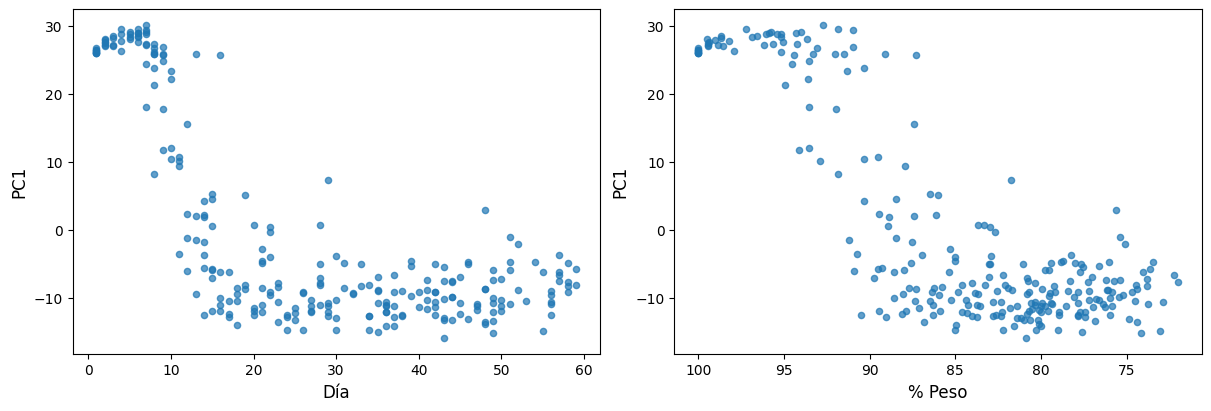

In [20]:
pc1 = X_pca[:,0]

fig, ax = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)
ax[0].scatter(y_day, pc1, s=20, alpha=0.7)
ax[0].set_xlabel("Día", fontsize=12)
ax[0].set_ylabel("PC1", fontsize=12)

ax[1].scatter(y_gr, pc1, s=20, alpha=0.7)
ax[1].set_xlabel("% Peso", fontsize=12)
ax[1].set_ylabel("PC1", fontsize=12)
ax[1].invert_xaxis()
plt.show()

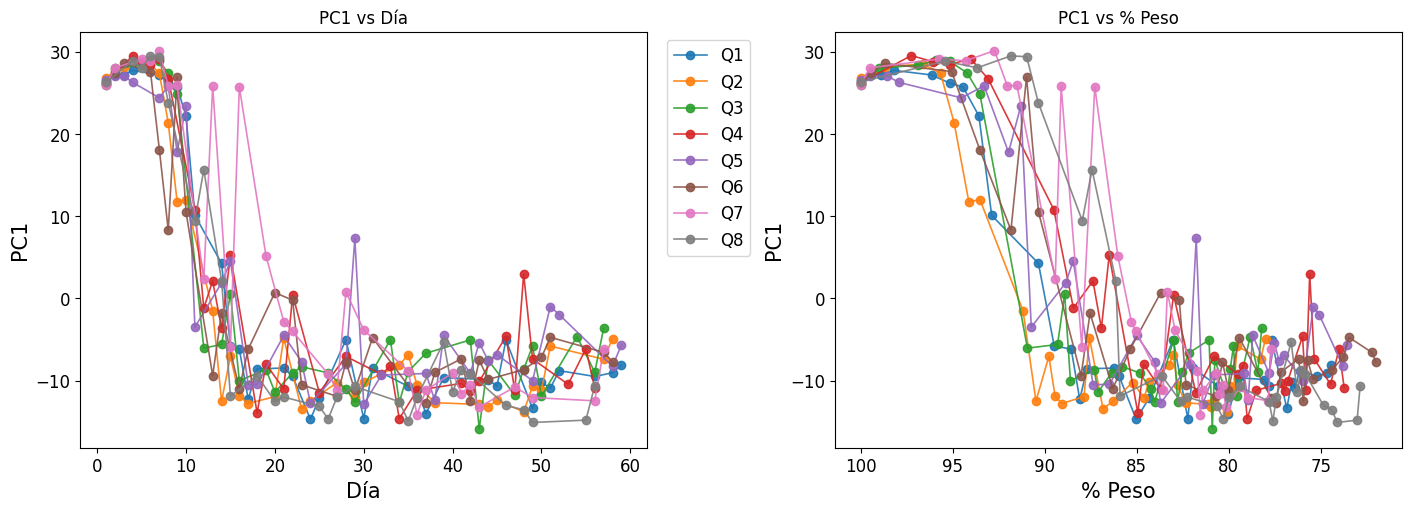

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14,5), constrained_layout=True)

for chs_id in np.sort(np.unique(cheese_id)):
  m = (cheese_id == chs_id)

  idx_d = np.argsort(y_day[m])
  ax[0].plot(np.array(y_day)[m][idx_d], pc1[m][idx_d], marker="o", linewidth=1.2, alpha=0.9, label=f"Q{chs_id}")

  idx_w = np.argsort(y_gr[m])
  ax[1].plot(np.array(y_gr)[m][idx_w], pc1[m][idx_w], marker="o", linewidth=1.2, alpha=0.9)

ax[0].set_xlabel("Día", fontsize=15)
ax[0].set_ylabel("PC1", fontsize=15)
ax[0].set_title("PC1 vs Día")
ax[0].tick_params(axis='both', labelsize=12)

ax[1].set_xlabel("% Peso", fontsize=15)
ax[1].set_ylabel("PC1", fontsize=15)
ax[1].set_title("PC1 vs % Peso")
ax[1].tick_params(axis='both', labelsize=12)
ax[1].invert_xaxis()
ax[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)
plt.show()

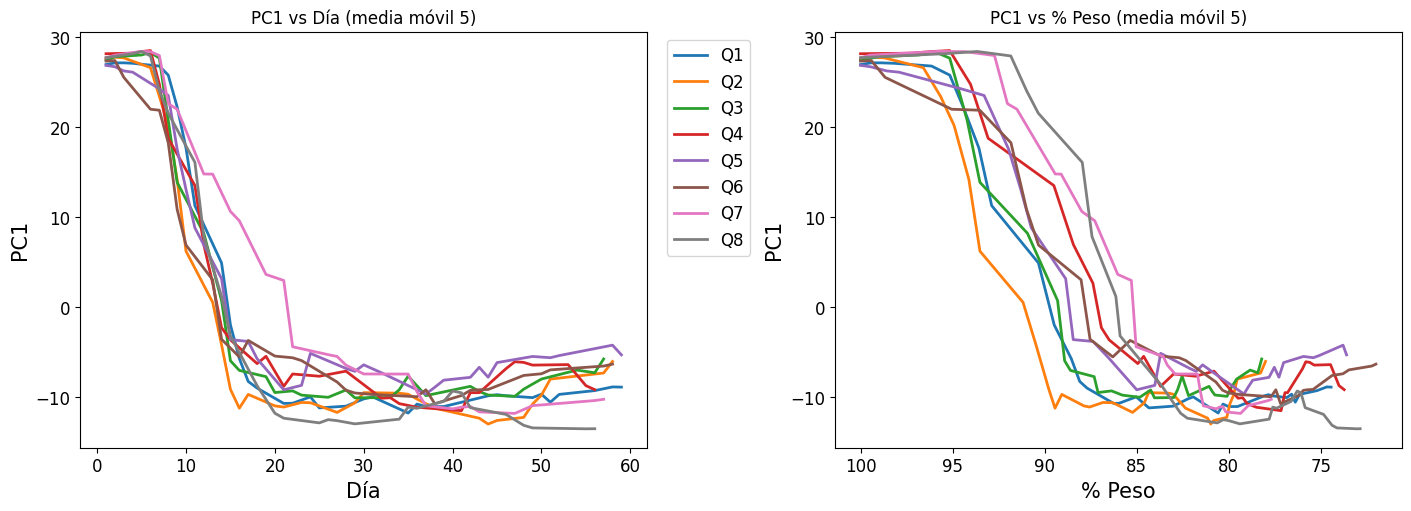

In [16]:
tmp = pd.DataFrame({"cheese_id": cheese_id.to_numpy(), "day": y_day.to_numpy(), "gr": y_gr.to_numpy(), "pc1": pc1})
w_size = 5

fig, ax = plt.subplots(1, 2, figsize=(14,5), constrained_layout=True)

for chs_id, g in tmp.groupby("cheese_id"):
  g1 = g.sort_values("day")
  smooth_day = g1["pc1"].rolling(window=w_size, center=True, min_periods=1).mean()
  ax[0].plot(g1["day"], smooth_day, linewidth=2, label=f"Q{chs_id}")

  g2 = g.dropna(subset=["gr"]).sort_values("gr")
  if len(g2) > 0:
    smooth_gr = g2["pc1"].rolling(window=w_size, center=True, min_periods=1).mean()
    ax[1].plot(g2["gr"], smooth_gr, linewidth=2)

ax[0].set_xlabel("Día", fontsize=15)
ax[0].set_ylabel("PC1", fontsize=15)
ax[0].set_title(f"PC1 vs Día (media móvil {w_size})")
ax[0].tick_params(axis='both', labelsize=12)
ax[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=12)

ax[1].set_xlabel("% Peso", fontsize=15)
ax[1].set_ylabel("PC1", fontsize=15)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].set_title(f"PC1 vs % Peso (media móvil {w_size})")
ax[1].invert_xaxis()

plt.show()

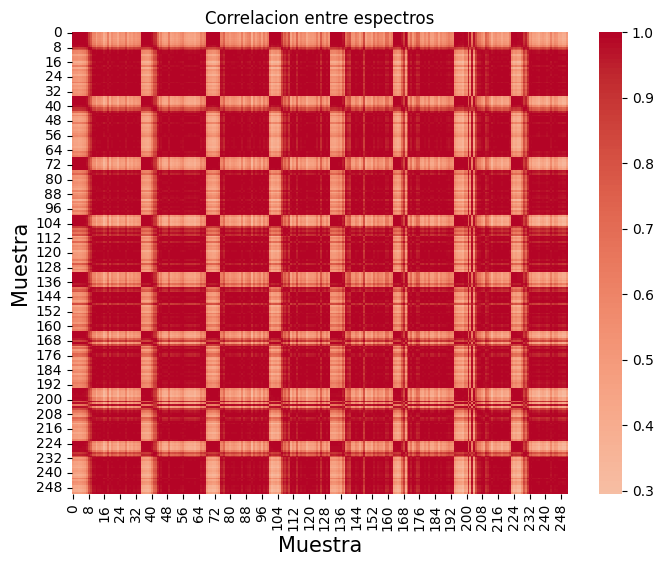

In [15]:
corr_samples = X.T.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_samples, cmap="coolwarm", center=0)
plt.title("Correlacion entre espectros")
plt.xlabel("Muestra", fontsize=15)
plt.ylabel("Muestra", fontsize=15)
plt.show()

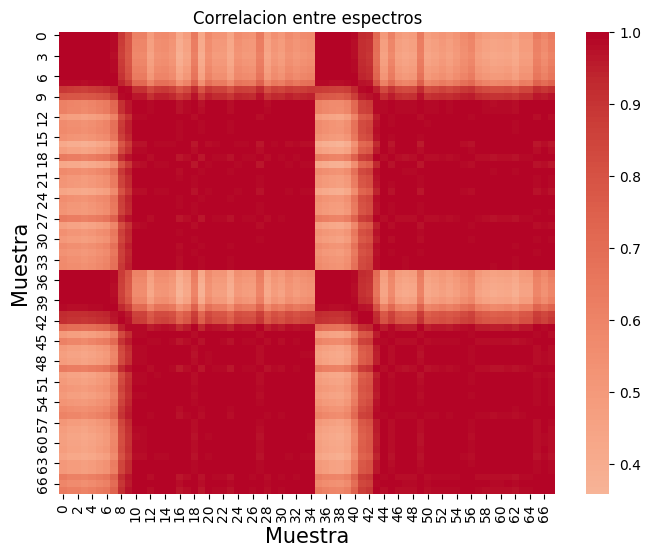

In [16]:
corr_samples = X.iloc[:68, :].T.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_samples, cmap="coolwarm", center=0)
plt.title("Correlacion entre espectros")
plt.xlabel("Muestra", fontsize=15)
plt.ylabel("Muestra", fontsize=15)
plt.show()

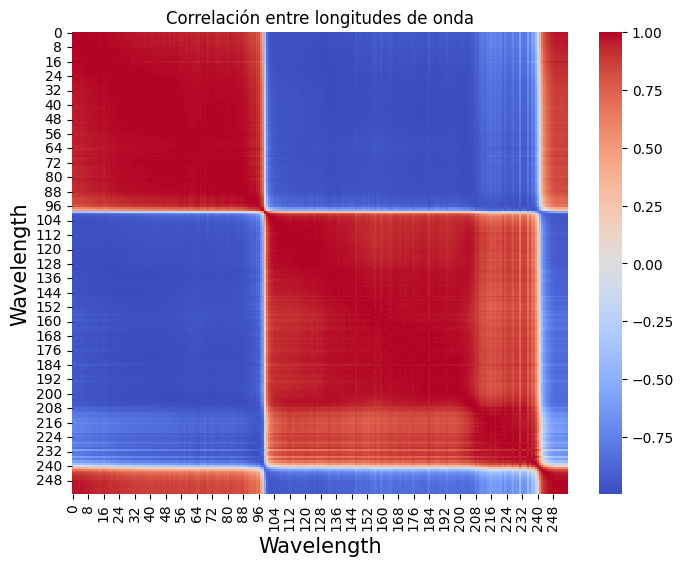

In [17]:
corr_wl = np.corrcoef(X, rowvar=False)
plt.figure(figsize=(8,6))
sns.heatmap(corr_wl, cmap="coolwarm", center=0)
plt.title("Correlación entre longitudes de onda")
plt.xlabel("Wavelength", fontsize=15)
plt.ylabel("Wavelength", fontsize=15)
plt.show()

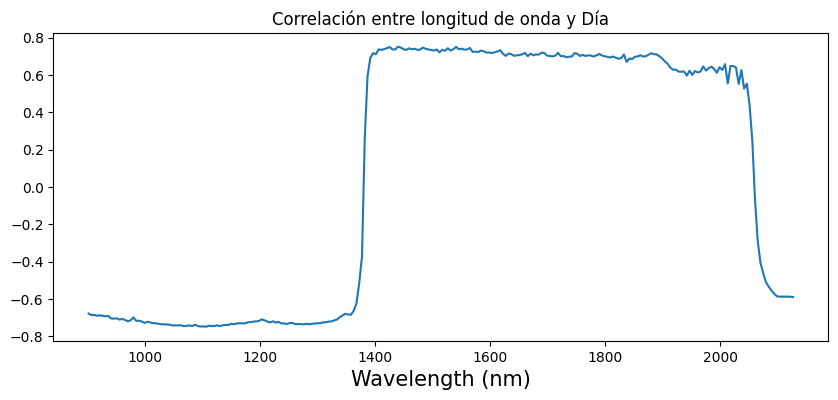

In [17]:
corrs = np.array([np.corrcoef(np.array(X)[:,j], y_day)[0,1] for j in range(np.array(X).shape[1])])
wl = X.columns.astype(float).to_numpy()

plt.figure(figsize=(10,4))
plt.plot(wl, corrs)
plt.xlabel("Wavelength (nm)", fontsize=15)
plt.title("Correlación entre longitud de onda y Día")
plt.show()

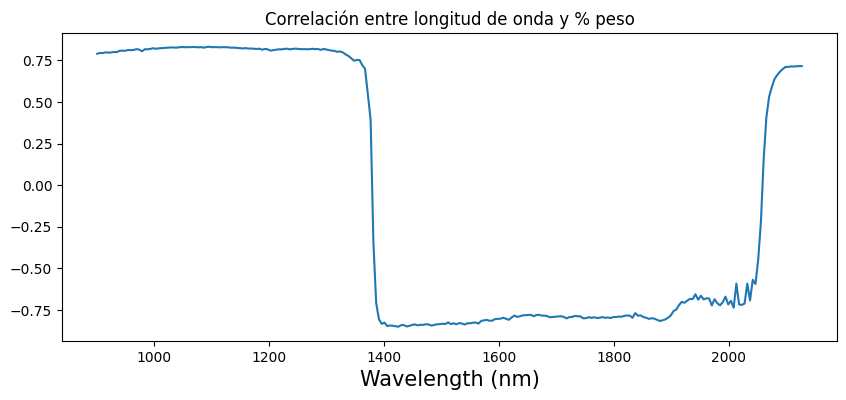

In [19]:
corrs = np.array([np.corrcoef(np.array(X)[:,j], y_gr)[0,1] for j in range(np.array(X).shape[1])])
wl = X.columns.astype(float).to_numpy()

plt.figure(figsize=(10,4))
plt.plot(wl, corrs)
plt.xlabel("Wavelength (nm)", fontsize=15)
plt.title("Correlación entre longitud de onda y % peso")
plt.show()